In [24]:
from utils import simulation
from utils import visualization
from utils import IO

In [37]:
original_data_path="/home/cyf/wbi/Virginia/221124_f338_ubi_gCaMP7f_bactin_mCherry_CAAX_7dpf002.nd2"
crop_region=[198,1580,0,256,256,13]
# our exp:
# r:5~20 default 20
# amp:1~10  default 5 no bigger than 12
# noise:1.4^0~1.4^9 default 5
# dat_mov_largeR, dat_ref_largeR, motion_largeR,_=simulation.generate_single_simulated_data(original_data_path,0,crop_region,
#                                                                                              r_value=40,#change
#                                                                                              amp_value=5,#change
#                                                                                              noise_level=5#change
#                                                                                              )
dat_mov_largeAmp, dat_ref_largeAmp, motion_largeAmp,_=simulation.generate_single_simulated_data(original_data_path,0,crop_region,
                                                                                             r_value=20,#change
                                                                                             amp_value=12,#change
                                                                                             noise_level=5#change
                                                                                             )

Loading raw data...
Z ratio is 27.69230769230769
Data size is (2304, 1708, 13)
Total frames is 1598
generation motion (R=20, Amp=10)...
apply motion
add noise (noise level: 5)
crop the data to the given region


Visualization
---

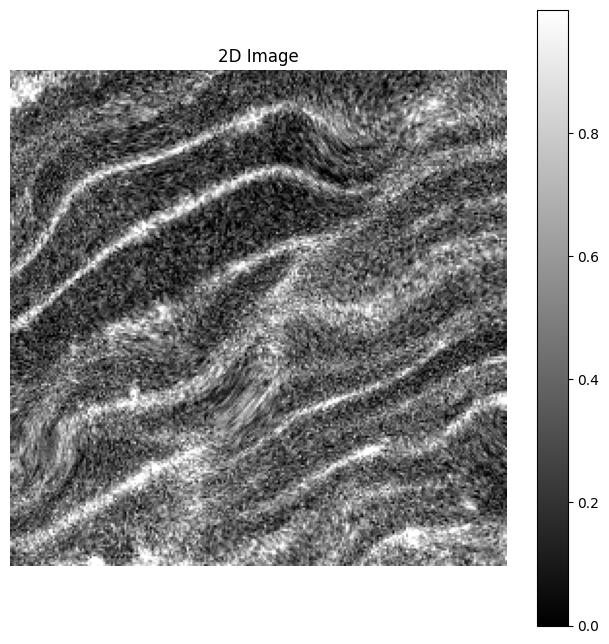

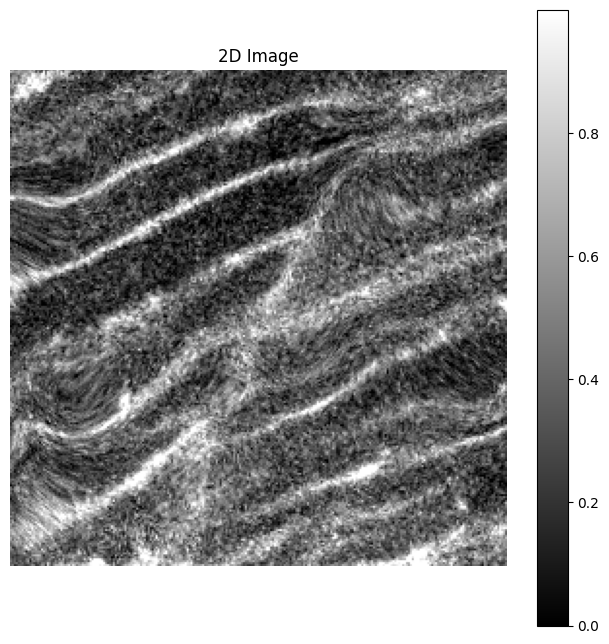

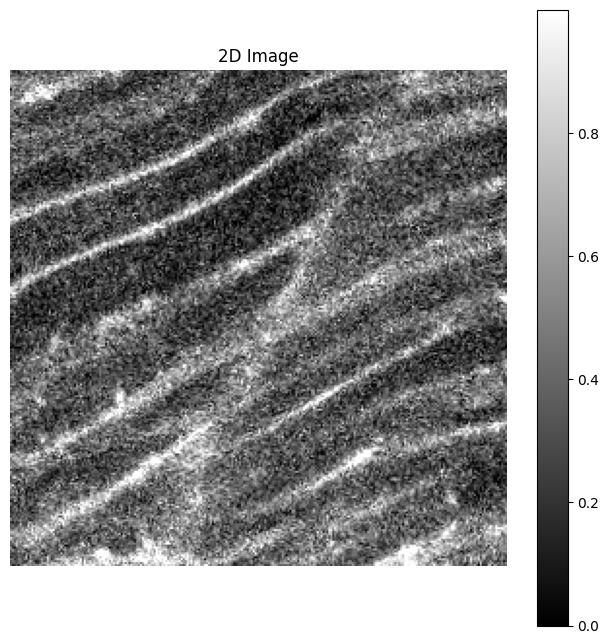

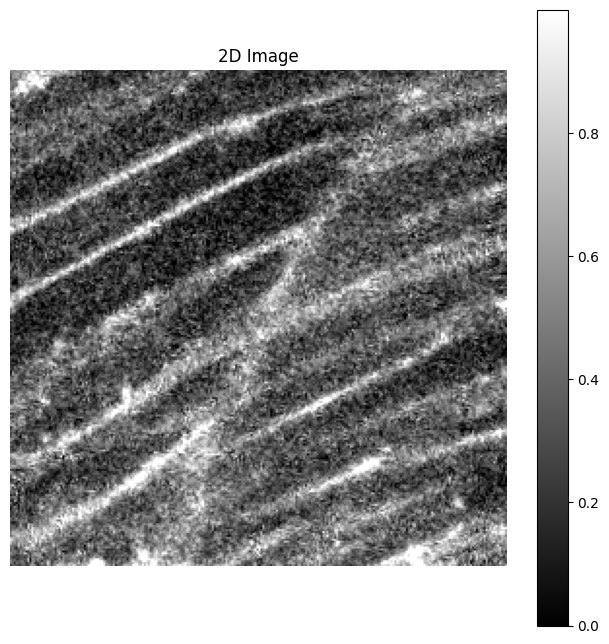

In [38]:
visualization.visualize_2d_image(dat_mov_largeAmp[:,:,0])
visualization.visualize_2d_image(dat_ref_largeAmp[:,:,0])

visualization.visualize_2d_image(dat_mov_largeR[:,:,0])
visualization.visualize_2d_image(dat_ref_largeR[:,:,0])

Save the result
---

In [42]:
import numpy as np
import tifffile
def saveTiff_simulation(filename,dat_ref,dat_mov):
    chan1_zyx = np.moveaxis(dat_ref, -1, 0).astype(np.float32)  # (256, 256, 13) → (13, 256, 256)
    chan2_zyx = np.moveaxis(dat_mov, -1, 0).astype(np.float32)  # (256, 256, 13) → (13, 256, 256)
    combined = np.stack((chan1_zyx, chan2_zyx), axis=1)
    tifffile.imwrite(
        filename,
        combined,
        imagej=True,  # 确保ImageJ兼容性
        metadata={
            'axes': 'ZCYX'  # 符合TZCYXS顺序（这里T=1可省略）
        },
        compression='zlib'
    )
saveTiff_simulation("./simulation/high_amp_comparison.tiff",dat_mov_largeAmp,dat_ref_largeAmp)
saveTiff_simulation("./simulation/high_r_comparison.tiff",dat_mov_largeR,dat_ref_largeR)
